In [85]:
!pip install -q pandas
!pip install -q numpy
!pip install -q torch
!pip install -q pandas-ta
!pip install -q yfinance
!pip install -q matplotlib
!pip install -q scipy
!pip install -q prophet
!pip install -q holidays
!pip install -q antropy
!pip install -q hurst
!pip install -q PyWavelets
!pip install -q librosa
!pip install -q TA-Lib
!pip install -q tsfresh


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip instal

In [86]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
import pandas_ta as ta
import holidays
from statsmodels.tsa.stattools import acf, pacf
from scipy.signal import argrelextrema
import antropy as ant
from hurst import compute_Hc
import numpy as np
import scipy
from scipy.fft import fft
import pywt

from scipy.signal import periodogram

import pywt
from scipy.stats import entropy as shannon_entropy

In [87]:
dat = yf.Ticker("BZ=F")
df = dat.history(period='5y')
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-06-14 00:00:00-04:00,72.489998,73.639999,72.489998,72.860001,25816,0.0,0.0
2021-06-15 00:00:00-04:00,73.099998,74.330002,72.779999,73.989998,32191,0.0,0.0
2021-06-16 00:00:00-04:00,74.300003,74.959999,73.889999,74.389999,42294,0.0,0.0
2021-06-17 00:00:00-04:00,73.980003,74.489998,72.000000,73.080002,42085,0.0,0.0
2021-06-18 00:00:00-04:00,73.070000,73.750000,72.180000,73.510002,26417,0.0,0.0


In [88]:
df.describe() 

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,1259.000000,1259.000000,1259.000000,1259.000000,1259.000000,1259.0,1259.0
mean,82.173630,83.565560,80.745655,82.185369,34214.091342,0.0,0.0
std,13.404070,14.036804,12.791001,13.425949,20201.071916,0.0,0.0
min,58.939999,60.410000,58.389999,58.919998,0.000000,0.0,0.0
25%,73.055000,73.915001,71.994999,73.005001,23428.000000,0.0,0.0
50%,80.150002,81.580002,79.080002,80.040001,31070.000000,0.0,0.0
75%,88.430000,89.919998,87.084999,88.389999,40600.500000,0.0,0.0
max,129.570007,137.000000,122.500000,127.980003,235965.000000,0.0,0.0


In [89]:
df = df.drop(['Dividends', 'Stock Splits'], axis=1)

df["body"] = df["Close"] - df["Open"]
df["range"] = df["High"] - df["Low"]
df["upper_wick"] = df["High"] - np.maximum(df["Open"], df["Close"])
df["lower_wick"] = np.minimum(df["Open"], df["Close"]) - df["Low"]
df["body_pct"] = df["body"] / df["Open"]
df["range_pct"] = df["range"] / df["Close"]
df["close_pos"] = (df["Close"] - df["Low"]) / df["range"]
df.head()

,Open,High,Low,Close,Volume,body,range,upper_wick,lower_wick,body_pct,range_pct,close_pos
Date,,,,,,,,,,,,
2021-06-14 00:00:00-04:00,72.489998,73.639999,72.489998,72.860001,25816,0.370003,1.150002,0.779999,0.000000,0.005104,0.015784,0.321741
2021-06-15 00:00:00-04:00,73.099998,74.330002,72.779999,73.989998,32191,0.889999,1.550003,0.340004,0.320000,0.012175,0.020949,0.780643
2021-06-16 00:00:00-04:00,74.300003,74.959999,73.889999,74.389999,42294,0.089996,1.070000,0.570000,0.410004,0.001211,0.014384,0.467290
2021-06-17 00:00:00-04:00,73.980003,74.489998,72.000000,73.080002,42085,-0.900002,2.489998,0.509995,1.080002,-0.012165,0.034072,0.433736
2021-06-18 00:00:00-04:00,73.070000,73.750000,72.180000,73.510002,26417,0.440002,1.570000,0.239998,0.889999,0.006022,0.021358,0.847135


In [90]:
columns = ['body', 'range', 'body_pct', 'range_pct', 'close_pos']

In [91]:
def analyze_distribution(df, column, bins=15):
    data = df[column].dropna()

    z_data = stats.zscore(data)

    mean = data.mean()
    median = data.median()
    q25, q75 = data.quantile([0.25, 0.75])


    fig, ax = plt.subplots(3, 1, figsize=(12, 12))


    ax[0].hist(data, edgecolor="black", bins=bins)

    ax[0].axvline(mean, color="red", linestyle="--", linewidth=2, label=f"Mean {mean:.2f}")
    ax[0].axvline(median, color="blue", linestyle="-", linewidth=2, label=f"Median {median:.2f}")
    ax[0].axvline(q25, color="green", linestyle=":", linewidth=2, label=f"Q25 {q25:.2f}")
    ax[0].axvline(q75, color="green", linestyle=":", linewidth=2, label=f"Q75 {q75:.2f}")

    ax[0].set_title(column)
    ax[0].legend()


    stats.probplot(data, dist='norm', plot=ax[1])
    ax[1].set_title(f'QQ {column}')


    ax[2].hist(z_data, edgecolor="black", bins=bins)
    ax[2].axvline(-3, color="red", linestyle="--")
    ax[2].axvline(3, color="red", linestyle="--")
    ax[2].set_title(f'Z-score {column}')


    plt.tight_layout()
    plt.show()

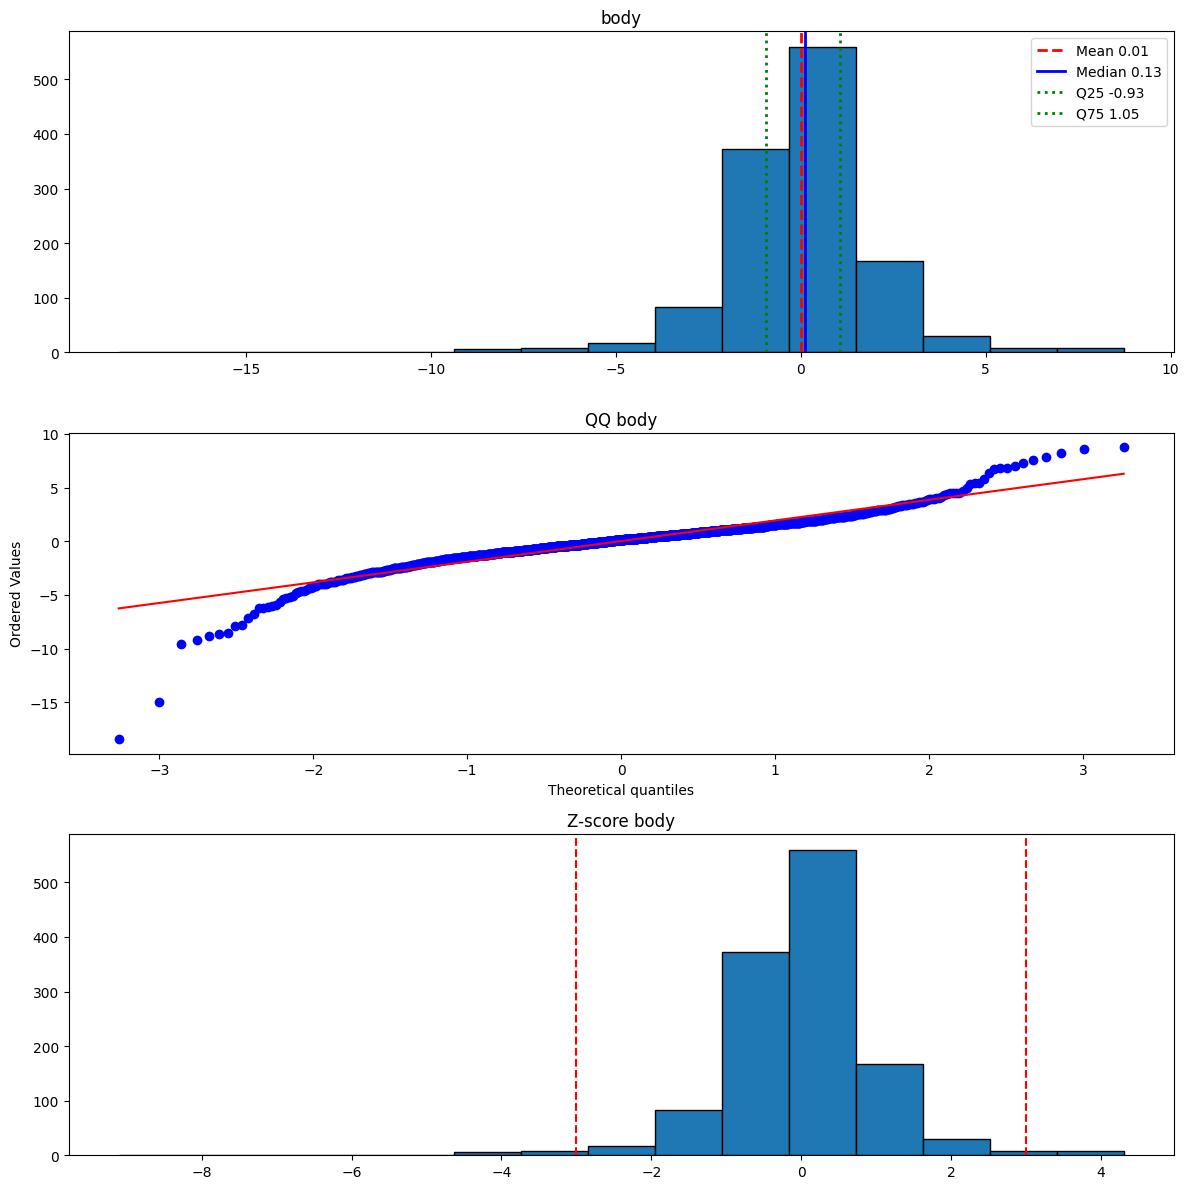

In [92]:
analyze_distribution(df, 'body')

In [93]:
from collections import defaultdict
from typing import Dict

def get_decomposition_result(
    df: pd.DataFrame
) -> Dict[str, Dict[str, pd.Series]]:
    
    result = defaultdict(dict)

    for column in df.columns:
        df_prophet = df[column].reset_index()
        df_prophet.columns = ["ds", "y"]
        df_prophet["ds"] = df_prophet["ds"].dt.tz_localize(None)

        model = Prophet()
        model.fit(df_prophet)

        forecast = model.predict(df_prophet)

        result[column]["trend"] = forecast["trend"]
        result[column]["seasonality"] = forecast["additive_terms"]
        result[column]["residuals"] = df_prophet["y"] - forecast["yhat"]

    return result


In [94]:
decomp = get_decomposition_result(df)

decomp["Open"]["trend"][0:5]

13:48:04 - cmdstanpy - INFO - Chain [1] start processing
13:48:05 - cmdstanpy - INFO - Chain [1] done processing
13:48:05 - cmdstanpy - INFO - Chain [1] start processing
13:48:05 - cmdstanpy - INFO - Chain [1] done processing
13:48:06 - cmdstanpy - INFO - Chain [1] start processing
13:48:06 - cmdstanpy - INFO - Chain [1] done processing
13:48:06 - cmdstanpy - INFO - Chain [1] start processing
13:48:07 - cmdstanpy - INFO - Chain [1] done processing
13:48:07 - cmdstanpy - INFO - Chain [1] start processing
13:48:07 - cmdstanpy - INFO - Chain [1] done processing
13:48:07 - cmdstanpy - INFO - Chain [1] start processing
13:48:07 - cmdstanpy - INFO - Chain [1] done processing
13:48:08 - cmdstanpy - INFO - Chain [1] start processing
13:48:08 - cmdstanpy - INFO - Chain [1] done processing
13:48:08 - cmdstanpy - INFO - Chain [1] start processing
13:48:08 - cmdstanpy - INFO - Chain [1] done processing
13:48:09 - cmdstanpy - INFO - Chain [1] start processing
13:48:09 - cmdstanpy - INFO - Chain [1]

0    66.588003
1    66.714771
2    66.841538
3    66.968306
4    67.095074
Name: trend, dtype: float64

In [95]:
def plot_decomposition(decomp, column):
    trend = decomp[column]["trend"]
    seasonality = decomp[column]["seasonality"]
    residuals = decomp[column]["residuals"]

    _, axes = plt.subplots(
        3, 1,
        figsize=(15, 10),
        sharex=True
    )

    axes[0].plot(trend)
    axes[0].set_title("Trend")
    axes[0].grid(True)

    axes[1].plot(seasonality)
    axes[1].set_title("Seasonality")
    axes[1].grid(True)

    axes[2].plot(residuals)
    axes[2].set_title("Residuals")
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

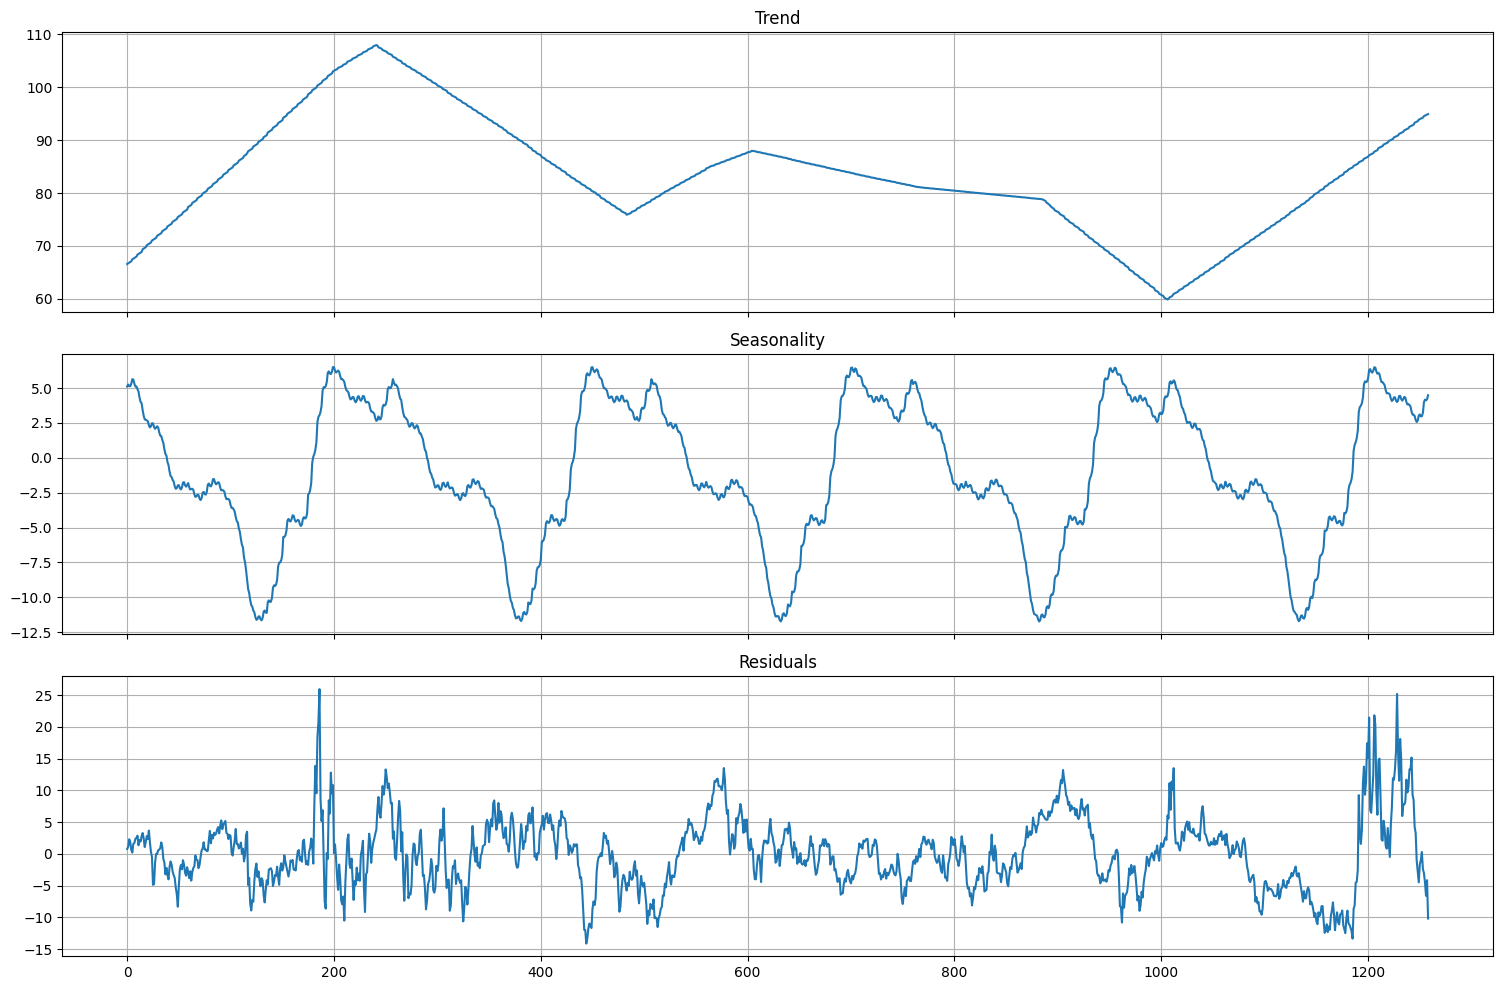

In [96]:
plot_decomposition(decomp, "Open")

- В последнее время много шума на графике в связи с последними событиями
- В последние дни тренд восходящий
- Во времена геополитической нестабильности шума становится больше (например 2022 г февраль на графике соответсвует примерно точке 200)

In [97]:
df_lag = df.diff(periods=1)
df_lag.columns = [f"{col}_diff_1" for col in df.columns]

df = pd.concat([df, df_lag], axis=1)
df = df.dropna()

In [98]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1258 entries, 2021-06-15 00:00:00-04:00 to 2026-06-12 00:00:00-04:00
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Open               1258 non-null   float64
 1   High               1258 non-null   float64
 2   Low                1258 non-null   float64
 3   Close              1258 non-null   float64
 4   Volume             1258 non-null   int64  
 5   body               1258 non-null   float64
 6   range              1258 non-null   float64
 7   upper_wick         1258 non-null   float64
 8   lower_wick         1258 non-null   float64
 9   body_pct           1258 non-null   float64
 10  range_pct          1258 non-null   float64
 11  close_pos          1258 non-null   float64
 12  Open_diff_1        1258 non-null   float64
 13  High_diff_1        1258 non-null   float64
 14  Low_diff_1         1258 non-null   float64
 15  Close_diff_1       1258 non-null   

In [99]:
for column in df.columns:
    stat, pvalue, *_ = sm.tsa.adfuller(df[column])
    print(column)
    if pvalue > 0.05: 
        print('Ряд не стационарен')
    else:
        print('Ряд стационарен')
    print('-' * 30)

Open
Ряд не стационарен
------------------------------
High
Ряд не стационарен
------------------------------
Low
Ряд не стационарен
------------------------------
Close
Ряд не стационарен
------------------------------
Volume
Ряд стационарен
------------------------------
body
Ряд стационарен
------------------------------
range
Ряд стационарен
------------------------------
upper_wick
Ряд стационарен
------------------------------
lower_wick
Ряд стационарен
------------------------------
body_pct
Ряд стационарен
------------------------------
range_pct
Ряд стационарен
------------------------------
close_pos
Ряд стационарен
------------------------------
Open_diff_1
Ряд стационарен
------------------------------
High_diff_1
Ряд стационарен
------------------------------
Low_diff_1
Ряд стационарен
------------------------------
Close_diff_1
Ряд стационарен
------------------------------
Volume_diff_1
Ряд стационарен
------------------------------
body_diff_1
Ряд стационарен
----------

Интегральный ряд первого порядка стационарен.

Проанализируем разницы, так как они стационарны и удобнее для анализа

In [100]:
decomp = get_decomposition_result(df)

13:48:11 - cmdstanpy - INFO - Chain [1] start processing
13:48:12 - cmdstanpy - INFO - Chain [1] done processing
13:48:12 - cmdstanpy - INFO - Chain [1] start processing
13:48:12 - cmdstanpy - INFO - Chain [1] done processing
13:48:13 - cmdstanpy - INFO - Chain [1] start processing
13:48:13 - cmdstanpy - INFO - Chain [1] done processing
13:48:13 - cmdstanpy - INFO - Chain [1] start processing
13:48:14 - cmdstanpy - INFO - Chain [1] done processing
13:48:14 - cmdstanpy - INFO - Chain [1] start processing
13:48:14 - cmdstanpy - INFO - Chain [1] done processing
13:48:14 - cmdstanpy - INFO - Chain [1] start processing
13:48:14 - cmdstanpy - INFO - Chain [1] done processing
13:48:15 - cmdstanpy - INFO - Chain [1] start processing
13:48:15 - cmdstanpy - INFO - Chain [1] done processing
13:48:15 - cmdstanpy - INFO - Chain [1] start processing
13:48:15 - cmdstanpy - INFO - Chain [1] done processing
13:48:16 - cmdstanpy - INFO - Chain [1] start processing
13:48:16 - cmdstanpy - INFO - Chain [1]

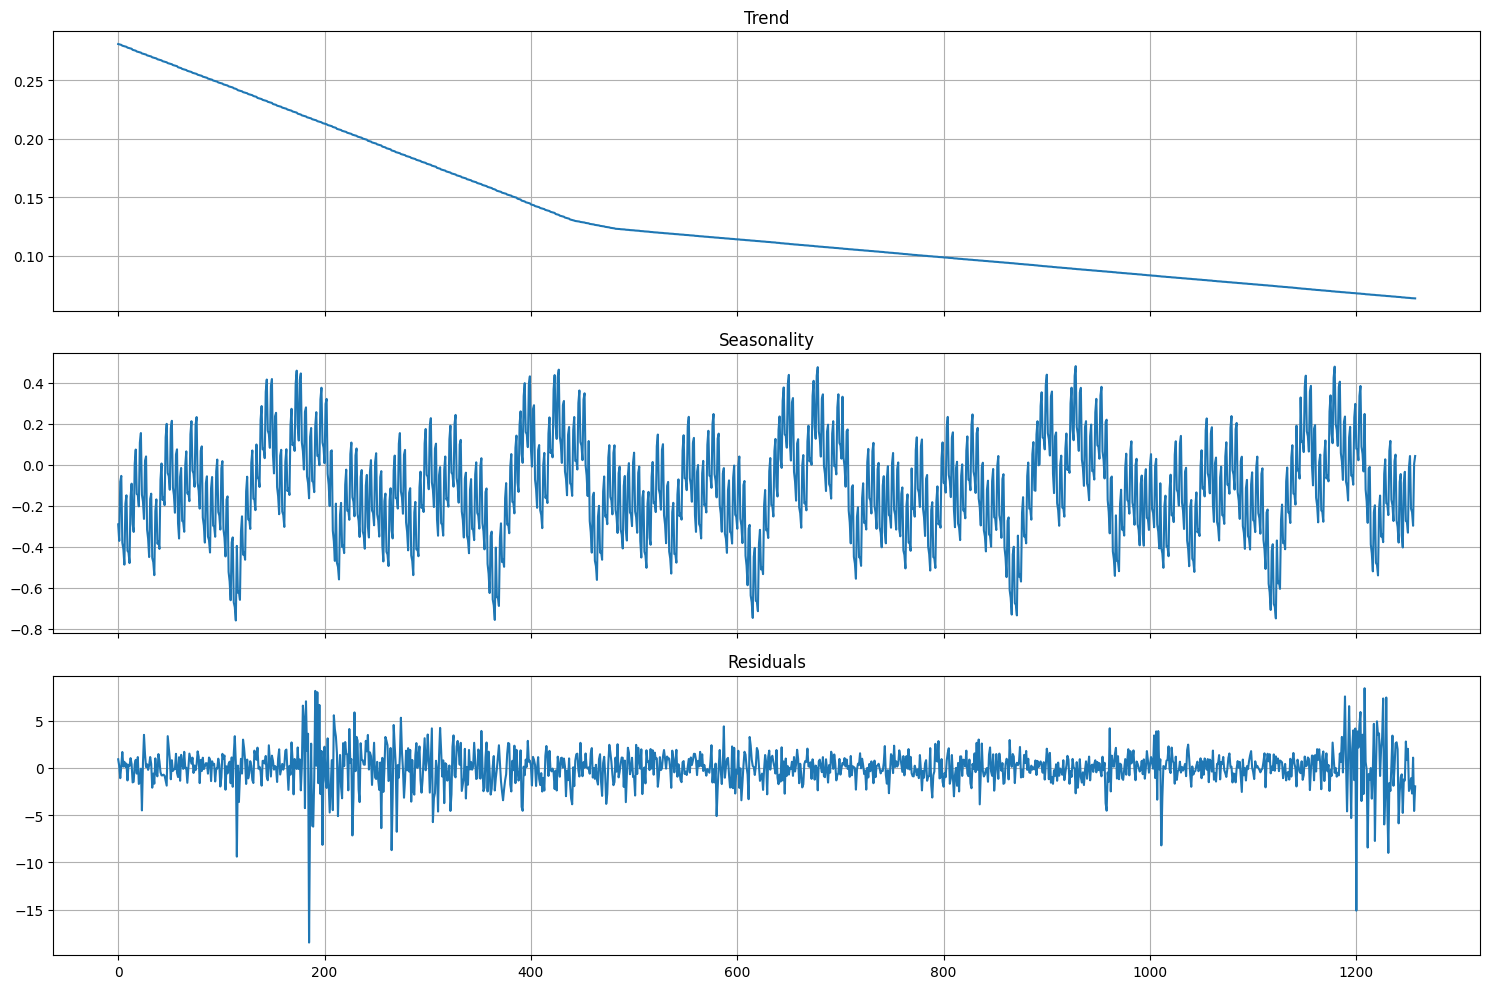

In [101]:
plot_decomposition(decomp, "body")

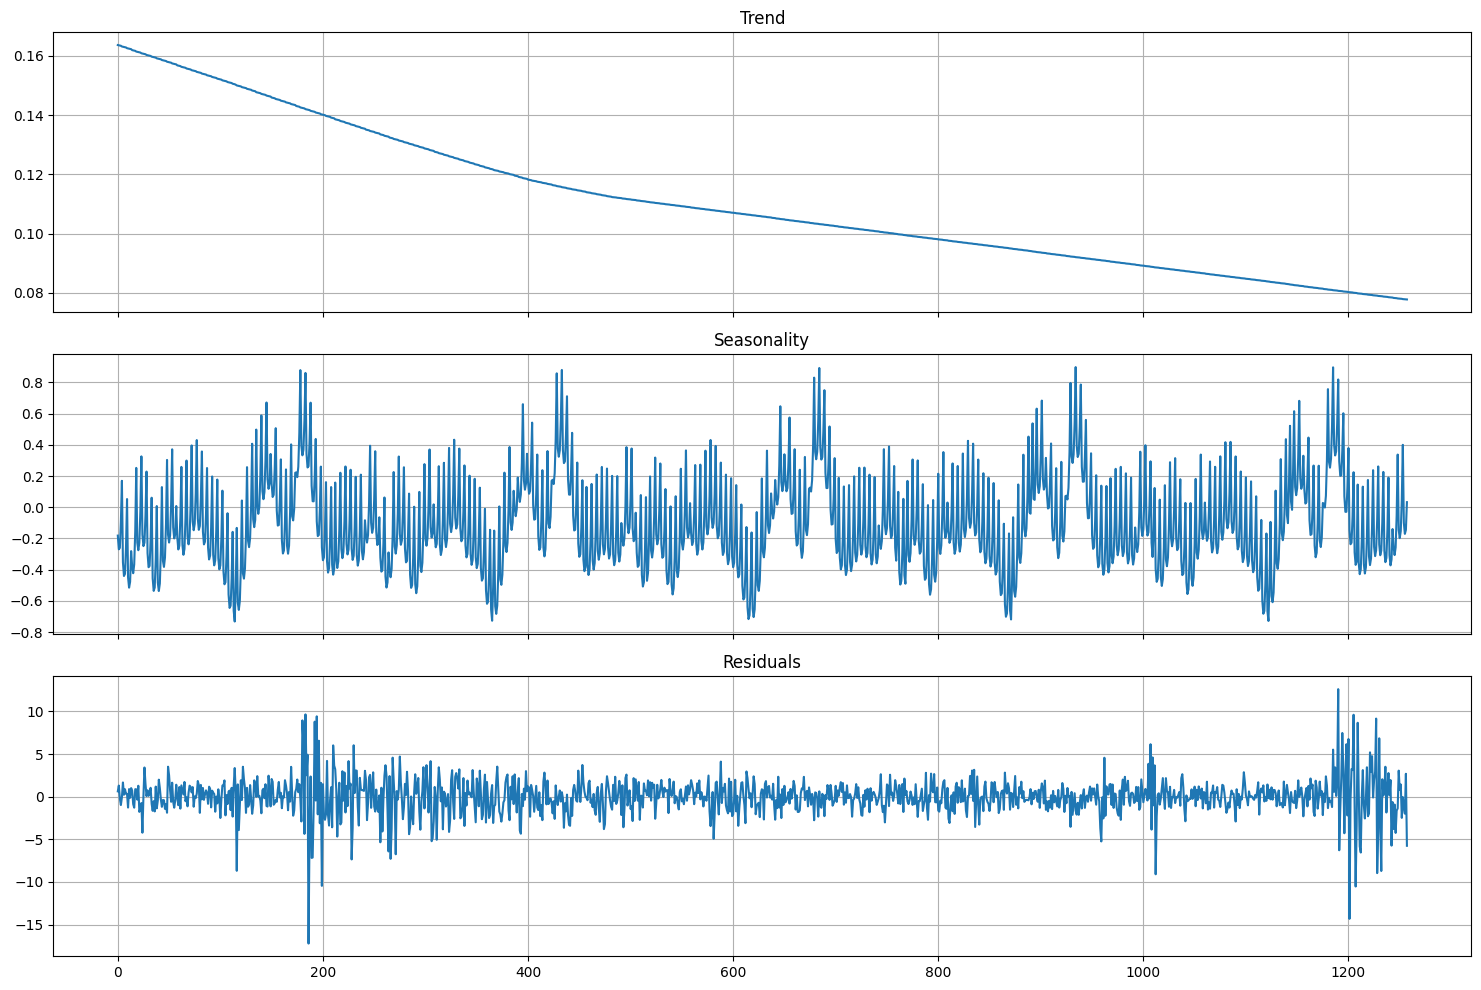

In [102]:
plot_decomposition(decomp, "Open_diff_1")

В целом характеристики графиков не изменились. Так же четко видно 2 всплеска шума. Тренд стал более сглаженным. Сезонность стала более зашумленной

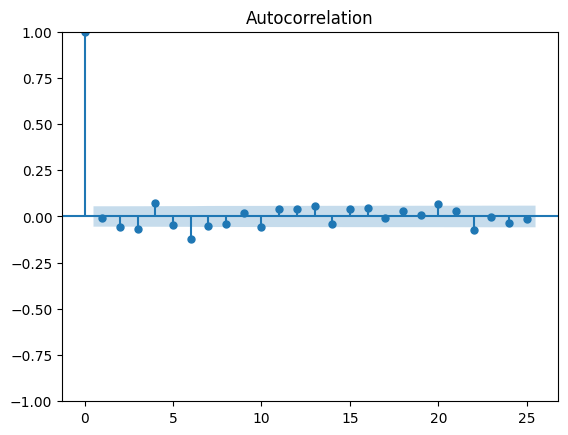

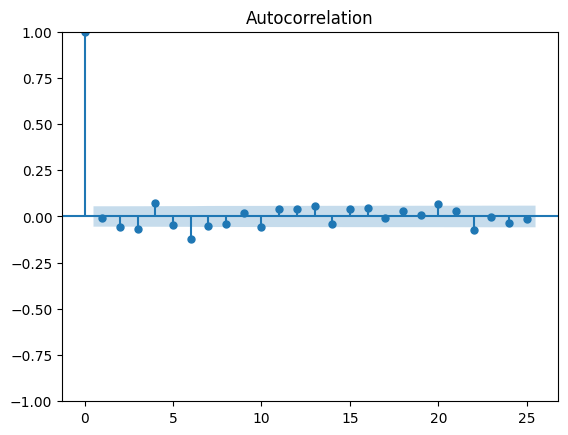

In [103]:
plot_acf(df["body"], lags=25)

Автокореляции нет

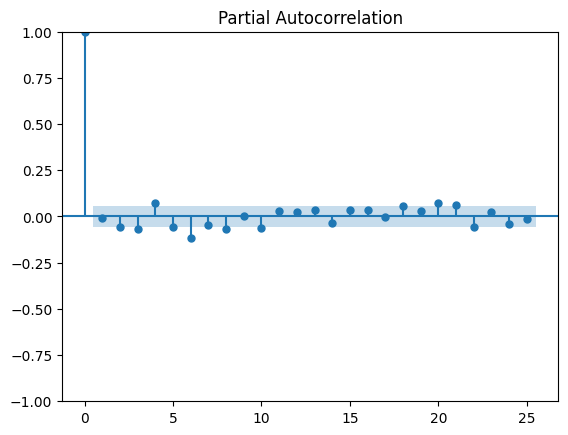

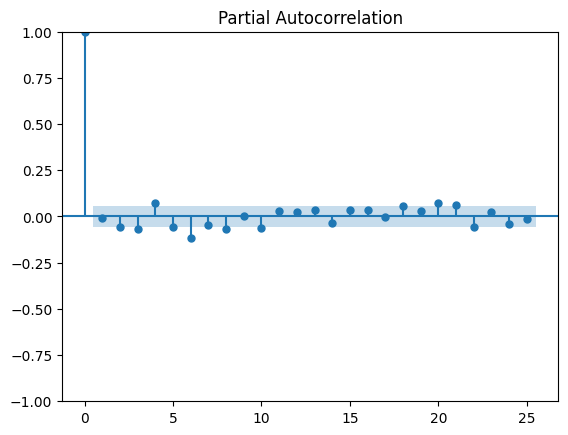

In [104]:
plot_pacf(df["body"], lags=25)

Частичной тоже.

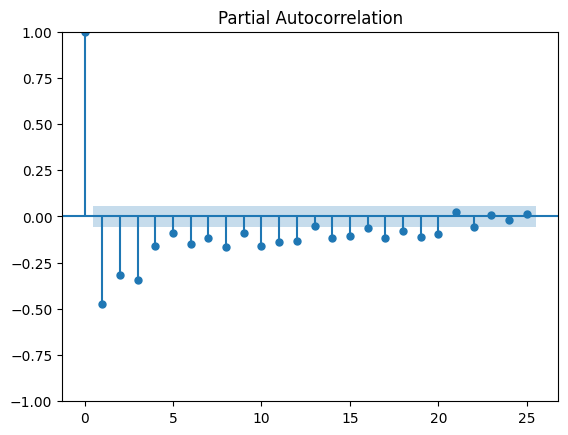

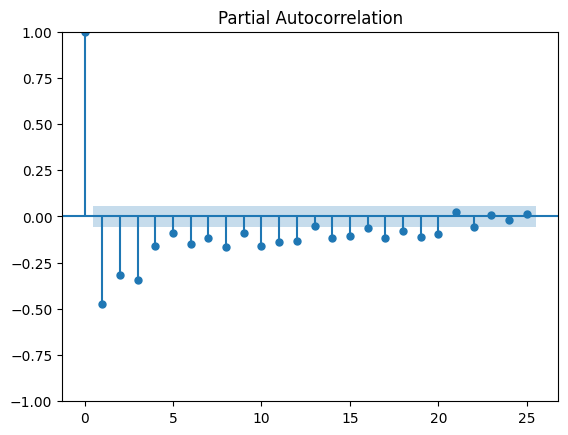

In [105]:
plot_pacf(df["body_diff_1"], lags=25)

Частиная автокореляция есть для первой разницы

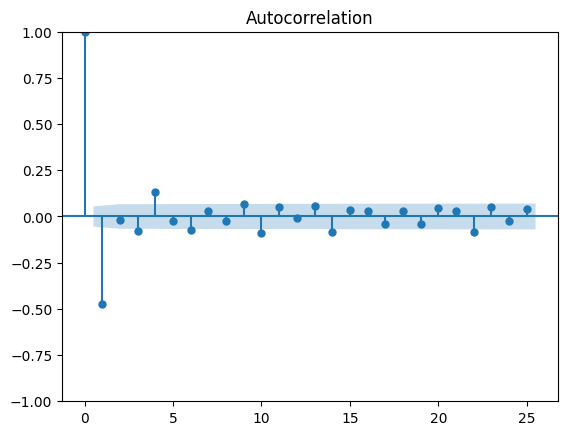

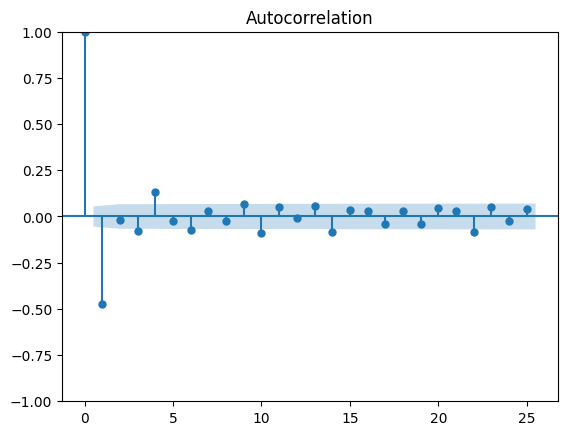

In [106]:
plot_acf(df["body_diff_1"], lags=25)

Для первой разницы есть автокореляция с первым лагом.

Возможно, это говорит о моментуме. То есть, если цена начала расти, то она с большей вероятностью будет расти на следующий день

In [107]:
stat, p_value = stats.shapiro(decomp["body"]["residuals"])

if p_value > 0.05:
    print(f"Остатки распределены нормально (p-value={p_value:.4f})")
else:
    print(f"Остатки НЕ распределены нормально (p-value={p_value:.4f})")

Остатки НЕ распределены нормально (p-value=0.0000)


In [108]:
stat, p_value = stats.shapiro(decomp["body_diff_1"]["residuals"])

if p_value > 0.05:
    print(f"Остатки распределены нормально (p-value={p_value:.4f})")
else:
    print(f"Остатки НЕ распределены нормально (p-value={p_value:.4f})")

Остатки НЕ распределены нормально (p-value=0.0000)


In [109]:
test = sm.stats.diagnostic.acorr_ljungbox(decomp["body"]["residuals"], lags=[50])
stat = test["lb_stat"].iloc[0]
p_value = test["lb_pvalue"].iloc[0]

if p_value > 0.05:
    print("Автокорреляция не обнаружена")
else:
    print("Есть автокорреляция")
print(f'p_value={p_value:.4f}')

Есть автокорреляция
p_value=0.0000


In [110]:
test = sm.stats.diagnostic.acorr_ljungbox(decomp["body_diff_1"]["residuals"], lags=[50])
stat = test["lb_stat"].iloc[0]
p_value = test["lb_pvalue"].iloc[0]

if p_value > 0.05:
    print("Автокорреляция не обнаружена")
else:
    print("Есть автокорреляция")
print(f'p_value={p_value:.4f}')

Есть автокорреляция
p_value=0.0000


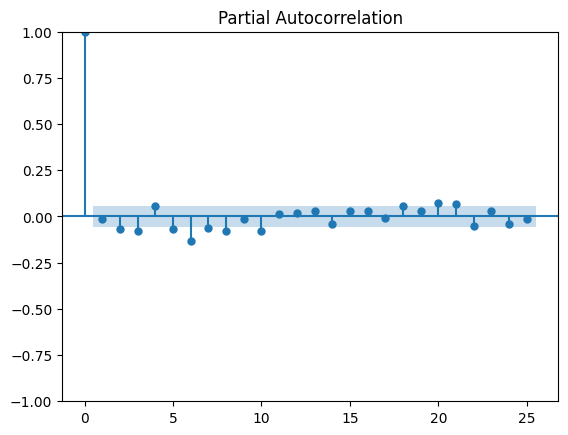

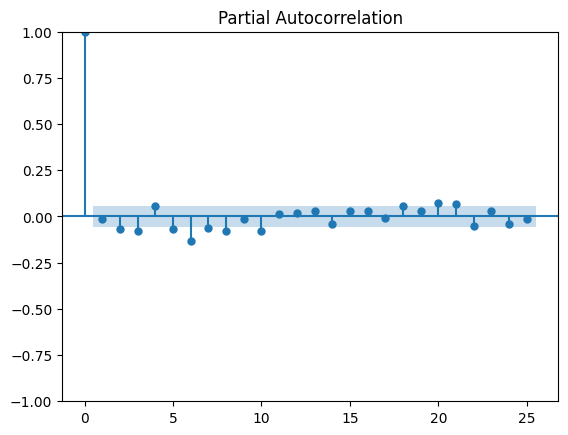

In [111]:
plot_pacf(decomp["body"]["residuals"], lags=25)

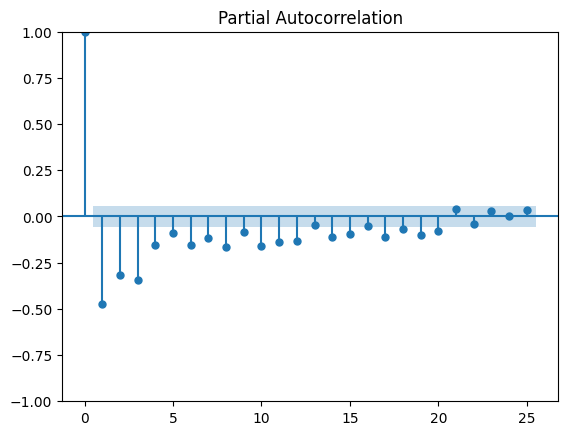

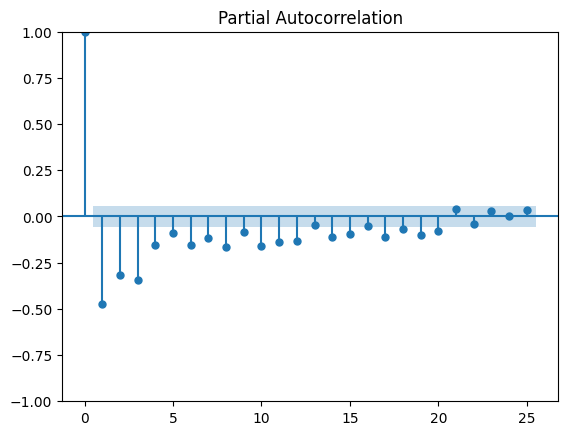

In [112]:
plot_pacf(decomp["body_diff_1"]["residuals"], lags=25, alpha=0.05)

Тесты показывают, что остатки автокоррелируют. То есть это не просто шум и шум содержит довольно много информации

In [113]:
features = []

for col in columns:

    features.extend(
        [
            df[col].shift(lag).rename(f"{col}_lag_{lag}")
            for lag in range(1, 31)
        ]
    )


    log_col = np.log(df[col].clip(lower=1e-9))

    features.extend(
        [
            log_col.shift(lag).rename(f"{col}_log_lag_{lag}")
            for lag in range(1, 11)
        ]
    )

    features.append(
        df[col].diff().diff().rename(f"{col}_diff2")
    )

In [114]:
windows = [4, 5, 7, 14, 21, 30]

for col in columns:
    for w in windows:
        features.append(
            df[col].rolling(window=w, min_periods=1).mean().rename(f"{col}_ma_{w}")
        )
        
        features.append(
            df[col].rolling(window=w, min_periods=1).median().rename(f"{col}_median_{w}")
        )
        
        features.append(
            df[col].rolling(window=w, min_periods=1).std().rename(f"{col}_std_{w}")
        )
        
        features.append(
            df[col].rolling(window=w, min_periods=1).min().rename(f"{col}_min_{w}")
        )
        
        features.append(
            df[col].rolling(window=w, min_periods=1).max().rename(f"{col}_max_{w}")
        )
        
        features.append(
            (df[col].rolling(window=w, min_periods=1).max() - 
             df[col].rolling(window=w, min_periods=1).min()).rename(f"{col}_range_{w}")
        )
        
        features.append(
            df[col].rolling(window=w, min_periods=1).var().rename(f"{col}_var_{w}")
        )
        
        features.append(
            df[col].rolling(window=w, min_periods=1).skew().rename(f"{col}_skew_{w}")
        )
        
        features.append(
            df[col].rolling(window=w, min_periods=1).kurt().rename(f"{col}_kurt_{w}")
        )
        
        features.append(
            df[col].rolling(window=w, min_periods=1).quantile(0.25).rename(f"{col}_q25_{w}")
        )
        
        features.append(
            df[col].rolling(window=w, min_periods=1).quantile(0.75).rename(f"{col}_q75_{w}")
        )
        
        q75 = df[col].rolling(window=w, min_periods=1).quantile(0.75)
        q25 = df[col].rolling(window=w, min_periods=1).quantile(0.25)
        features.append(
            (q75 - q25).rename(f"{col}_iqr_{w}")
        )

In [115]:
lengths = [10, 20, 30, 40, 50]

for col in columns:
    for length in lengths:

        features.append(
            ta.ema(df[col], length=length).rename(f"{col}_ema_{length}")
        )

        features.append(
            ta.dema(df[col], length=length).rename(f"{col}_dema_{length}")
        )

        features.append(
            ta.tema(df[col], length=length).rename(f"{col}_tema_{length}")
        )

        features.append(
            ta.kama(df[col], length=length).rename(f"{col}_kama_{length}")
        )

In [116]:
stoch = ta.stoch(
    high=df["High"],
    low=df["Low"],
    close=df["Close"]
)

features.append(
    stoch.iloc[:, 0].rename("stoch_k")
)

features.append(
    stoch.iloc[:, 1].rename("stoch_d")
)

for length in [14, 21, 30]:
    features.append(
        ta.willr(
            high=df["High"],
            low=df["Low"],
            close=df["Close"],
            length=length
        ).rename(f"willr_{length}")
    )

adx = ta.adx(
    high=df["High"],
    low=df["Low"],
    close=df["Close"]
)

features.append(
    adx["ADX_14"].rename("adx")
)

features.append(
    adx["DMP_14"].rename("plus_di")
)

features.append(
    adx["DMN_14"].rename("minus_di")
)

features.append(
    ta.atr(
        high=df["High"],
        low=df["Low"],
        close=df["Close"],
        length=14
    ).rename("atr")
)

psar = ta.psar(
    high=df["High"],
    low=df["Low"],
    close=df["Close"]
)
psar_filled = psar.ffill().bfill()

for c in psar_filled.columns:
    features.append(
        psar_filled[c].rename(c.lower())
    )

# VWAP
features.append(
    ta.vwap(
        high=df["High"],
        low=df["Low"],
        close=df["Close"],
        volume=df["Volume"]
    ).rename("vwap")
)

# OBV
features.append(
    ta.obv(
        close=df["Close"],
        volume=df["Volume"]
    ).rename("obv")
)

# Accumulation / Distribution
features.append(
    ta.ad(
        high=df["High"],
        low=df["Low"],
        close=df["Close"],
        volume=df["Volume"]
    ).rename("ad")
)

In [117]:
for col in columns:

    # RSI
    for length in [14, 21, 30]:
        features.append(
            ta.rsi(
                df[col],
                length=length
            ).rename(f"{col}_rsi_{length}")
        )

    # ROC
    for length in [5, 10, 20]:
        features.append(
            ta.roc(
                df[col],
                length=length
            ).rename(f"{col}_roc_{length}")
        )

    # Momentum
    for length in [5, 10, 20]:
        features.append(
            ta.mom(
                df[col],
                length=length
            ).rename(f"{col}_mom_{length}")
        )

    # MACD
    macd = ta.macd(df[col])

    features.append(
        macd.iloc[:, 0].rename(f"{col}_macd")
    )

    features.append(
        macd.iloc[:, 1].rename(f"{col}_macd_signal")
    )

    features.append(
        macd.iloc[:, 2].rename(f"{col}_macd_hist")
    )

    # Bollinger Bands
    bb = ta.bbands(
        df[col],
        length=20
    )

    for c in bb.columns:
        features.append(
            bb[c].rename(f"{col}_{c.lower()}")
        )

    # Volatility Ratio
    for length in [10, 20]:

        short_std = df[col].rolling(length).std()
        long_std = df[col].rolling(length * 2).std()

        features.append(
            (short_std / long_std).rename(
                f"{col}_volatility_ratio_{length}"
            )
        )

In [118]:
idx = pd.DatetimeIndex(df.index)
features.append(
    pd.Series(
        idx.is_month_start.astype(bool),
        index=idx,
        name="month_start"
    )
)

features.append(
    pd.Series(
        idx.is_month_end.astype(bool),
        index=idx,
        name="month_end"
    )
)

features.append(
    pd.Series(
        idx.is_quarter_start.astype(bool),
        index=idx,
        name="quarter_start"
    )
)

features.append(
    pd.Series(
        idx.is_quarter_end.astype(bool),
        index=idx,
        name="quarter_end"
    )
)


features.append(pd.Series(np.sin(2 * np.pi * idx.dayofweek / 7), index=idx, name="dayofweek_sin"))
features.append(pd.Series(np.cos(2 * np.pi * idx.dayofweek / 7), index=idx, name="dayofweek_cos"))


features.append(pd.Series(np.sin(2 * np.pi * idx.dayofyear / 366), index=idx, name="dayofyear_sin"))
features.append(pd.Series(np.cos(2 * np.pi * idx.dayofyear / 366), index=idx, name="dayofyear_cos"))

features.append(pd.Series(np.sin(2 * np.pi * idx.month / 12), index=idx, name="month_sin"))
features.append(pd.Series(np.cos(2 * np.pi * idx.month / 12), index=idx, name="month_cos"))

time_delta_days = (idx - idx[0]).days.astype(np.float32)

features.append(
    pd.Series(time_delta_days, index=idx, name="time_trend")
)

In [119]:
us_holidays = holidays.US()

features.append(
    pd.Series(
        idx.normalize().isin(us_holidays).astype(bool),
        index=idx,
        name="is_us_holiday"
    )
)

holiday_mask = idx.normalize().isin(us_holidays)

features.append(
    pd.Series(
        np.roll(holiday_mask, 1).astype(bool),
        index=idx,
        name="day_after_holiday"
    )
)

features.append(
    pd.Series(
        np.roll(holiday_mask, -1).astype(bool),
        index=idx,
        name="day_before_holiday"
    )
)

In [120]:
def extract_ts_features(series, idx):
    x = np.asarray(series.dropna(), dtype=np.float64)
    if len(x) < 30:
        return []

    x_centered = x - np.mean(x)
    x_norm = (x - np.mean(x)) / (np.std(x) + 1e-10)
    name = series.name

    def _const(val):
        return pd.Series(val, index=idx, name=name)

    feats = []

    lags = [1, 2, 3, 7, 14, 30]
    lags = [lag for lag in lags if lag < len(x) // 2]


    acf_vals = acf(x, nlags=max(lags))
    for lag in lags:
        feats.append(_const(acf_vals[lag]).rename(f"{name}_acf_lag_{lag}"))

    pacf_vals = pacf(x, nlags=max(lags))
    for lag in lags:
        feats.append(_const(pacf_vals[lag]).rename(f"{name}_pacf_lag_{lag}"))

    feats.append(_const(ant.app_entropy(x_norm)).rename(f"{name}_app_entropy"))

    feats.append(_const(ant.sample_entropy(x_norm)).rename(f"{name}_sample_entropy"))

    feats.append(_const(ant.perm_entropy(x_norm, order=3, delay=1, normalize=True)).rename(f"{name}_perm_entropy"))

    feats.append(_const(ant.spectral_entropy(x_norm, sf=1, method="welch", normalize=True)).rename(f"{name}_spectral_entropy"))


    H, c, _ = compute_Hc(x, kind="change", simplified=True)
    feats.append(_const(H).rename(f"{name}_hurst_h"))
    feats.append(_const(c).rename(f"{name}_hurst_c"))


    feats.append(_const(ant.higuchi_fd(x_norm)).rename(f"{name}_higuchi_fd"))

    feats.append(_const(ant.petrosian_fd(x_norm)).rename(f"{name}_petrosian_fd"))


    feats.append(_const(ant.detrended_fluctuation(x_norm)).rename(f"{name}_dfa"))

    mobility, complexity = ant.hjorth_params(x_norm)
    feats.append(_const(mobility).rename(f"{name}_hjorth_mobility"))
    feats.append(_const(complexity).rename(f"{name}_hjorth_complexity"))

    binary = (x >= np.median(x)).astype(int)
    feats.append(_const(ant.lziv_complexity(binary, normalize=True)).rename(f"{name}_lziv_complexity"))

    feats.append(_const(np.mean(x)).rename(f"{name}_mean"))
    feats.append(_const(np.std(x)).rename(f"{name}_std"))
    feats.append(_const(np.std(x) / (np.abs(np.mean(x)) + 1e-10)).rename(f"{name}_cv"))
    feats.append(_const(np.sum(x ** 2)).rename(f"{name}_signal_energy"))

    feats.append(_const(ant.num_zerocross(x_centered)).rename(f"{name}_zero_crossings"))

    peaks = argrelextrema(x, np.greater, order=5)[0]
    valleys = argrelextrema(x, np.less, order=5)[0]
    feats.append(_const(len(peaks)).rename(f"{name}_n_peaks"))
    feats.append(_const(len(valleys)).rename(f"{name}_n_valleys"))
    feats.append(_const((len(peaks) + len(valleys)) / len(x)).rename(f"{name}_extrema_ratio"))


    sorted_x = np.sort(np.abs(x) + 1e-10)
    n = len(sorted_x)
    index = np.arange(1, n + 1)
    gini = (2 * np.sum(index * sorted_x)) / (n * np.sum(sorted_x)) - (n + 1) / n
    feats.append(_const(gini).rename(f"{name}_gini"))

    return feats


for col in columns:
    features.extend(extract_ts_features(df[col], df.index))

In [121]:

# TODO: разобраться с частотными признаками
    
            

In [122]:
patterns_df = df.ta.cdl_pattern(
    name=[
        "doji",
        "hammer",
        "engulfing",
        "shootingstar",
        "hangingman",
        "morningstar",
        "eveningstar"
    ],
    append=False
)

                           CDL_DOJI_10_0.1  CDL_HAMMER  CDL_ENGULFING  \
Date                                                                    
2021-06-15 00:00:00-04:00              0.0         0.0            0.0   
2021-06-16 00:00:00-04:00              0.0         0.0            0.0   
2021-06-17 00:00:00-04:00              0.0         0.0            0.0   
2021-06-18 00:00:00-04:00              0.0         0.0            0.0   
2021-06-21 00:00:00-04:00              0.0         0.0            0.0   
...                                    ...         ...            ...   
2026-06-08 00:00:00-04:00              0.0         0.0            0.0   
2026-06-09 00:00:00-04:00              0.0         0.0            0.0   
2026-06-10 00:00:00-04:00              0.0         0.0            0.0   
2026-06-11 00:00:00-04:00              0.0         0.0         -100.0   
2026-06-12 00:00:00-04:00              0.0         0.0            0.0   

                           CDL_SHOOTINGSTAR  CDL_H

In [123]:
features_df = pd.concat(features, axis=1)
df = pd.concat([df, features_df, patterns_df], axis=1)
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'body', 'range', 'upper_wick',
       'lower_wick', 'body_pct',
       ...
       'close_pos_n_valleys', 'close_pos_extrema_ratio', 'close_pos_gini',
       'CDL_DOJI_10_0.1', 'CDL_HAMMER', 'CDL_ENGULFING', 'CDL_SHOOTINGSTAR',
       'CDL_HANGINGMAN', 'CDL_MORNINGSTAR', 'CDL_EVENINGSTAR'],
      dtype='str', length=986)

In [124]:
df['target'] = df['body'].shift(-1)


C:\Users\odo20\AppData\Local\Temp\ipykernel_20076\2727018165.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['target'] = df['body'].shift(-1)


In [125]:
df = df.dropna()


In [126]:
df.to_csv('data.csv')

In [127]:
df.time_trend

Date
2022-01-12 00:00:00-05:00     211.0
2022-01-13 00:00:00-05:00     212.0
2022-01-14 00:00:00-05:00     213.0
2022-01-18 00:00:00-05:00     217.0
2022-01-19 00:00:00-05:00     218.0
                              ...  
2026-06-05 00:00:00-04:00    1816.0
2026-06-08 00:00:00-04:00    1819.0
2026-06-09 00:00:00-04:00    1820.0
2026-06-10 00:00:00-04:00    1821.0
2026-06-11 00:00:00-04:00    1822.0
Name: time_trend, Length: 1103, dtype: float32